In [1]:
# import important libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
import joblib

In [2]:
# import dataset
data = load_breast_cancer()
dataset = pd.DataFrame(data.data,columns=data.feature_names)
dataset["target"] = data.target
dataset

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
# chesk dataset shape
dataset.shape

(569, 31)

In [4]:
# check dataset null values
dataset.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [5]:
# check dataset duplicated values
dataset.duplicated().sum()

np.int64(0)

In [6]:
# dataset.drop_duplicates(inplace=True)

In [7]:
# dataset.duplicated().sum()

In [8]:
# check dataset description
dataset.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [9]:
# check dataset information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

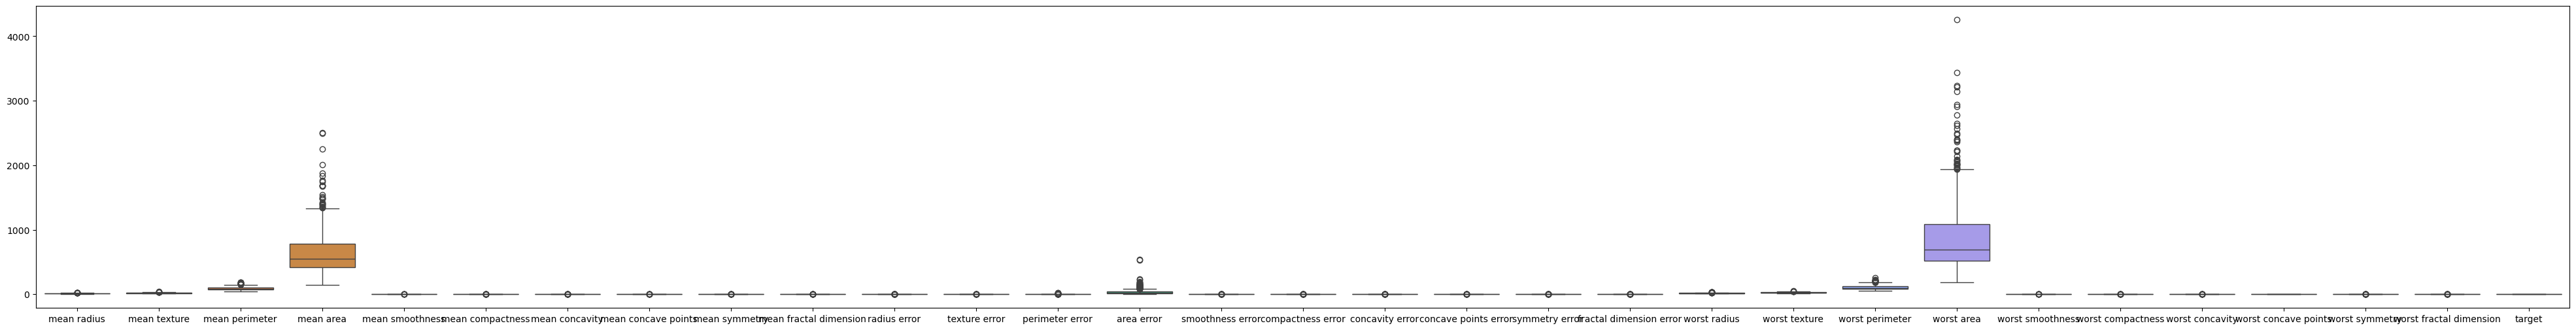

In [10]:
# chech outlier present or not
plt.figure(figsize=(50,6))
sns.boxplot(dataset)
plt.show()

In [11]:
# calculate Q1, Q2, and IQR for remove outlier
q1 = dataset["worst area"].quantile(0.25)
q3 = dataset["worst area"].quantile(0.75)
iqr = q3 - q1

# calculate minimum and maximum range
min_range = q1 - (1.5 * iqr)
max_range = q3 + (1.5 * iqr)

In [12]:
# get data under the minimum and maximum range
dataset = dataset[(dataset["worst area"] > min_range) & (dataset["worst area"] < max_range)]

In [13]:
# show new dataset
dataset

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.17910,0.52490,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.14420,0.25760,0.3784,0.1932,0.3063,0.08368,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.2542,0.2929,0.09873,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


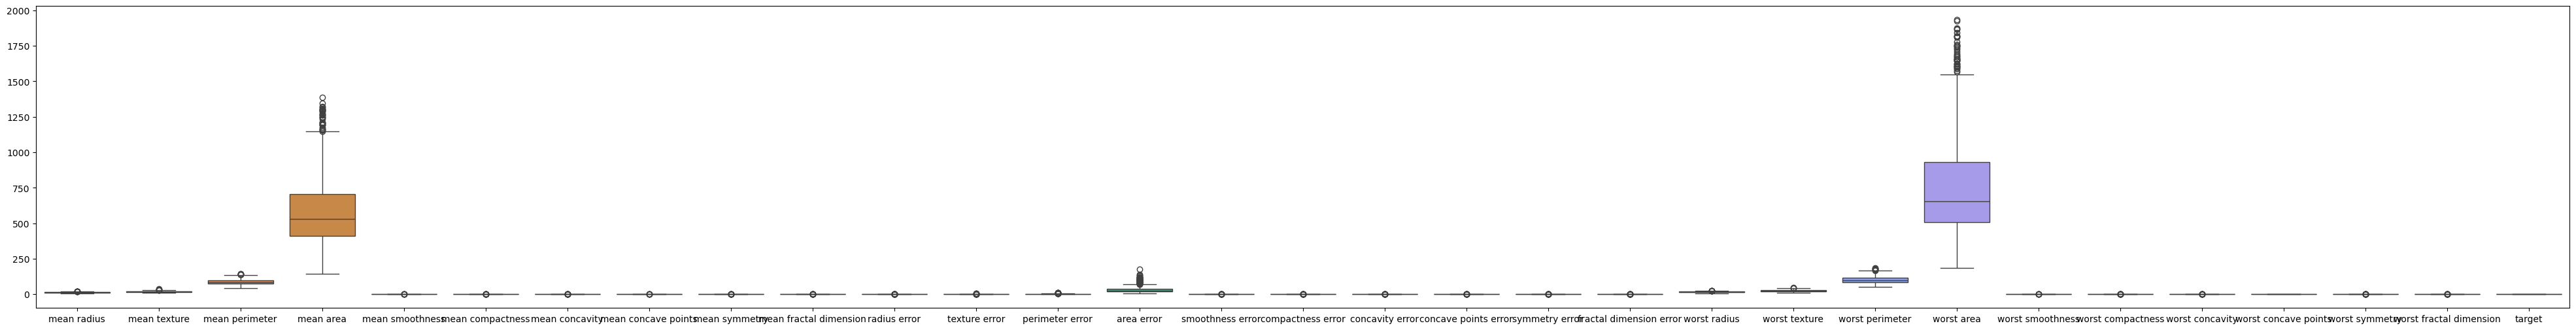

In [14]:
# check outlier remove or not
plt.figure(figsize=(50,6))
sns.boxplot(dataset)
plt.show()

In [15]:
# check new dataset shape
dataset.shape

(534, 31)

In [16]:
# sepearate dataset into independent and dependent
x = dataset.iloc[:,:-1]
y = dataset["target"]

In [17]:
# scaled data
sc = StandardScaler()
x_sc = sc.fit_transform(x)
x = pd.DataFrame(x_sc,columns=x.columns)
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,2.083726,0.496772,2.075220,2.282760,0.993250,1.205183,1.680285,2.564203,0.982137,-0.418806,...,2.106436,0.012296,1.892964,2.339787,0.558204,1.165568,0.967668,2.255137,1.196819,0.207445
1,-0.752911,0.292724,-0.541486,-0.799516,3.355798,3.708289,2.308977,1.872329,2.938212,4.879137,...,-0.153477,0.171642,-0.115266,-0.530539,3.402055,4.037683,2.144756,2.496004,6.176040,4.887696
2,2.289528,-1.123883,2.329802,2.637435,0.325417,0.658133,1.688858,1.844898,0.018919,-0.582908,...,1.837647,-1.443177,1.881730,2.002782,0.253817,-0.261388,0.716822,0.917906,-0.859064,-0.384299
3,-0.399617,-0.804912,-0.292395,-0.456160,2.300191,1.409065,1.114462,1.131384,1.048822,1.864473,...,-0.007340,-0.280113,0.054365,-0.093187,2.067097,1.818262,1.391221,1.110600,1.809140,2.224851
4,1.589802,0.198909,1.556072,1.667739,-0.081745,0.177698,0.470052,0.921383,-0.036651,-0.782377,...,1.926373,0.362201,1.919176,2.080746,0.549508,0.080562,0.609316,1.427881,0.291506,-0.006240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529,2.505620,1.397396,2.724155,2.826092,1.014793,2.491053,3.394900,3.158545,1.278512,0.826104,...,2.294327,0.649682,2.889027,2.616433,0.397314,1.127213,2.010374,2.441186,0.070939,0.818365
530,2.234648,2.138535,2.135122,2.501602,0.145893,0.064655,0.917281,1.650137,-0.192248,-1.078043,...,2.137751,2.101869,1.986579,2.395116,-0.650649,-0.344600,0.326118,0.922889,-0.516691,-0.954673
531,1.023846,2.098664,0.991998,0.981405,-0.805589,0.042450,0.181569,0.281933,-0.792408,-0.915356,...,0.908630,1.423415,0.926857,0.868534,-0.768056,0.417310,0.419688,0.574046,-1.099383,-0.306495
532,2.395859,2.391836,2.579393,2.516695,1.582092,3.569003,3.880707,3.298748,2.197275,1.019914,...,2.672719,2.294071,3.094980,2.621462,1.453974,4.049384,3.397994,2.620591,1.977034,2.202935


In [18]:
# split data into train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
# choose multiple models for best get best model into them
models = {
    "LogisticRegression":LogisticRegression(),
    "SVC":SVC(probability=True),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(n_estimators=100)
}

In [20]:
# train each model
for name,model in models.items():
    model.fit(x_train,y_train)
    print(name,"trained")

LogisticRegression trained
SVC trained
Decision Tree trained
Random Forest trained


In [21]:
# chech each model score
for name,model in models.items():
    print("model:",name)
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:,1]
    print("train_score:",model.score(x_train,y_train)*100)
    print("test_score:",model.score(x_test,y_test)*100)
    print("accuracy_score:",accuracy_score(y_test,y_pred)*100)
    print("recall_score:",recall_score(y_test,y_pred)*100)
    print("f1_score:",f1_score(y_test,y_pred)*100)
    print("roc_auc_score:",roc_auc_score(y_test,y_pred_proba)*100)
    print()

model: LogisticRegression
train_score: 99.06323185011709
test_score: 95.32710280373831
accuracy_score: 95.32710280373831
recall_score: 95.94594594594594
f1_score: 96.5986394557823
roc_auc_score: 99.54954954954954

model: SVC
train_score: 98.59484777517564
test_score: 94.39252336448598
accuracy_score: 94.39252336448598
recall_score: 95.94594594594594
f1_score: 95.94594594594594
roc_auc_score: 99.42669942669943

model: Decision Tree
train_score: 100.0
test_score: 86.91588785046729
accuracy_score: 86.91588785046729
recall_score: 87.83783783783784
f1_score: 90.27777777777779
roc_auc_score: 86.34316134316136

model: Random Forest
train_score: 100.0
test_score: 88.78504672897196
accuracy_score: 88.78504672897196
recall_score: 91.8918918918919
f1_score: 91.8918918918919
roc_auc_score: 96.39639639639638



In [22]:
# predict x_test using best model
y_pred = models["SVC"].predict(x_test)

In [23]:
# see confusion matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[30,  3],
       [ 3, 71]])

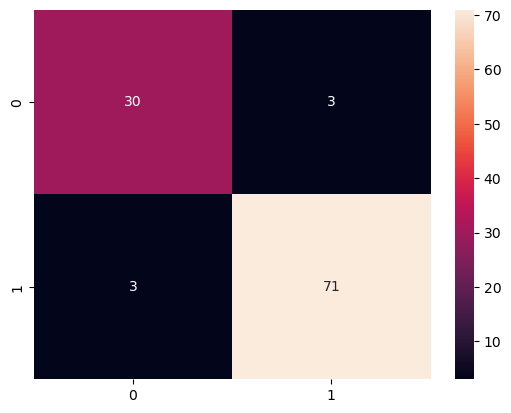

In [24]:
# see confusion matrix using heatmap
sns.heatmap(cm,annot=True)
plt.show()

#convert model into file to use another file

In [26]:
joblib.dump(models["SVC"],"breast.joblib")

['breast.joblib']